# **Final Project Task 1 - Census Data Preprocess**

Requirements

- Target variable specification:
    - The target variable for this project is hours-per-week. 
    - Ensure all preprocessing steps are designed to support regression analysis on this target variable.
- Encode data  **3p**
- Handle missing values if any **1p**
- Correct errors, inconsistencies, remove duplicates if any **1p**
- Outlier detection and treatment if any **1p**
- Normalization / Standardization if necesarry **1p**
- Feature engineering **3p**
- Train test split, save it.
- Others?


Deliverable:

- Notebook code with no errors.
- Preprocessed data as csv.

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable




[notice] A new release of pip is available: 24.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
pip cache purge

Files removed: 430
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

data = pd.read_csv(data_url, header=None, names=columns, na_values=" ?", skipinitialspace=True)
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [40]:
# Identifying the number of cases
rows, columns = data.shape
print(f"Numărul de rânduri: {rows}") 

Numărul de rânduri: 32561


In [41]:
# Replacing '?' in categorical variables with their mode.
#counting '?' values in each column
question_marks = (data == '?').sum()
print(question_marks)

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [42]:
# Handle missing values
data.replace('?', pd.NA, inplace=True)
columns_with_missing = ["workclass", "occupation", "native-country"]
for col in columns_with_missing:
    mode_value = data[col].mode()[0]  # Calculating mode 
    data[col].fillna(mode_value, inplace=True)  # Replace NaN with mode

C:\Users\Alexandra Bande\AppData\Local\Temp\ipykernel_18164\1137386853.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(mode_value, inplace=True)  # Replace NaN with mode


In [43]:
# Checking for remaining NaN values
print(data[columns_with_missing].isnull().sum())

workclass         0
occupation        0
native-country    0
dtype: int64


In [44]:
# Identifying duplicates in the dataset
numar_duplicate = data.duplicated().sum()
print(f"Numărul de duplicate: {numar_duplicate}")

Numărul de duplicate: 24


In [45]:
# Visualizing duplicates
duplicate_rows = data[data.duplicated()]
print(duplicate_rows)

       age         workclass  fnlwgt     education  education-num  \
4881    25           Private  308144     Bachelors             13   
5104    90           Private   52386  Some-college             10   
9171    21           Private  250051  Some-college             10   
11631   20           Private  107658  Some-college             10   
13084   25           Private  195994       1st-4th              2   
15059   21           Private  243368     Preschool              1   
17040   46           Private  173243       HS-grad              9   
18555   30           Private  144593       HS-grad              9   
18698   19           Private   97261       HS-grad              9   
21318   19           Private  138153  Some-college             10   
21490   19           Private  146679  Some-college             10   
21875   49           Private   31267       7th-8th              4   
22300   25           Private  195994       1st-4th              2   
22367   44           Private  3677

In [46]:
# Removing duplicates to improve data quality and analysis consistency
data.drop_duplicates(inplace=True)

In [47]:
# Remove leading and trailing whitespaces from string values
data = data.applymap(lambda x: x.strip() if isinstance(x, str) else x)
# Convert specific columns to integer type
data = data.astype({"age": int, "fnlwgt": int, "education-num": int, "capital-gain": int, "capital-loss": int, "hours-per-week": int})

C:\Users\Alexandra Bande\AppData\Local\Temp\ipykernel_18164\658217508.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [48]:
# Implementing the feature engineering process for the 'age' variable
# Creating the age_group variable
bins = [0, 25, 35, 45, 55, 65, 100]
labels = [1, 2, 3, 4, 5, 6]
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False).astype(int)
data = data.drop('age', axis=1)

In [50]:
# verifYing for datatypes errors
print(data.dtypes)

workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
age_group          int64
dtype: object


In [51]:
data.head()

,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_group
0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,3
1,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,4
2,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,3
3,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,4
4,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,2


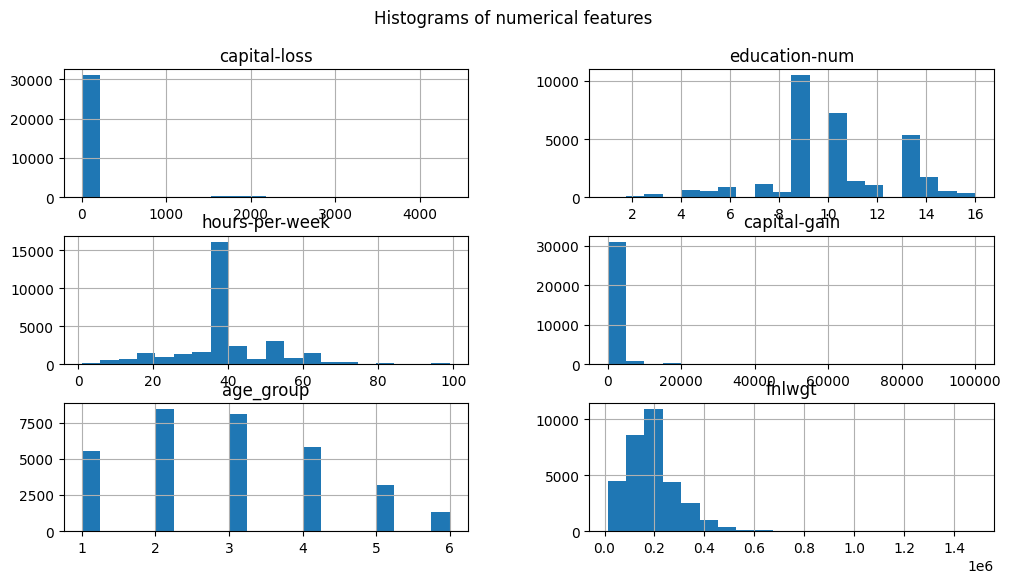

In [52]:
# Visualizing the distributions of numerical features
# Crearea boxplot-urilor
# Histograms for numerical columns
numerical_columns = ["capital-loss", "education-num", "hours-per-week", "capital-gain", "age_group", "fnlwgt"]
data[numerical_columns].hist(bins=20, figsize=(12, 6))
plt.suptitle("Histograms of numerical features")
plt.show()

In [53]:
# Eliminating columns with many outliers and categorical columns that will not be useful for my regression model.
data.drop(columns=['capital-gain', 'capital-loss', 'fnlwgt', 'occupation', 'native-country', 'education', 'relationship'], inplace=True)

In [54]:
data.head()

,workclass,education-num,marital-status,race,sex,hours-per-week,income,age_group
0,State-gov,13,Never-married,White,Male,40,<=50K,3
1,Self-emp-not-inc,13,Married-civ-spouse,White,Male,13,<=50K,4
2,Private,9,Divorced,White,Male,40,<=50K,3
3,Private,7,Married-civ-spouse,Black,Male,40,<=50K,4
4,Private,13,Married-civ-spouse,Black,Female,40,<=50K,2


In [55]:
# Define the target variable
y = data['hours-per-week']

# Remove the target variable from the feature set
X = data.drop(columns=['hours-per-week'])

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:

# Checking the dimensions of the training and testing sets.
print(f"Dimensiunea setului de antrenament X: {X_train.shape}")
print(f"Dimensiunea setului de test X: {X_test.shape}")
print(f"Dimensiunea setului de antrenament y: {y_train.shape}")
print(f"Dimensiunea setului de test y: {y_test.shape}")

Dimensiunea setului de antrenament X: (26029, 7)
Dimensiunea setului de test X: (6508, 7)
Dimensiunea setului de antrenament y: (26029,)
Dimensiunea setului de test y: (6508,)


In [57]:
X_train.head()

,workclass,education-num,marital-status,race,sex,income,age_group
32239,Private,9,Separated,White,Female,<=50K,3
30377,Private,9,Divorced,White,Male,<=50K,4
5457,Private,10,Married-civ-spouse,White,Male,>50K,2
19700,Private,9,Divorced,Black,Male,<=50K,4
23197,Private,9,Married-civ-spouse,White,Male,<=50K,2


In [58]:
X_test.head()

,workclass,education-num,marital-status,race,sex,income,age_group
3643,State-gov,11,Married-civ-spouse,White,Male,<=50K,2
16042,Federal-gov,13,Never-married,White,Male,<=50K,1
9404,Local-gov,10,Married-civ-spouse,Asian-Pac-Islander,Male,<=50K,5
17910,Private,10,Never-married,White,Male,<=50K,2
5200,Federal-gov,13,Never-married,White,Male,>50K,3


In [59]:
y_train.head()


32239    38
30377    40
5457     40
19700    40
23197    55
Name: hours-per-week, dtype: int64

In [60]:
y_test.head()

3643     40
16042    40
9404     60
17910    40
5200     40
Name: hours-per-week, dtype: int64

In [61]:
# Select only the numerical features from X_train and X_test
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['int64', 'float64'])

# Calculating the IQR on numerical features
Q1 = X_train_numeric.quantile(0.25)
Q3 = X_train_numeric.quantile(0.75)
IQR = Q3 - Q1

# Defining the bounds for identifying outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Removing outliers from the training set
X_train_numeric_no_outliers = X_train_numeric[~((X_train_numeric < lower_bound) | (X_train_numeric > upper_bound)).any(axis=1)]
y_train_no_outliers = y_train.loc[X_train_numeric_no_outliers.index]

# Checking the number of rows remaining after removing the outliers
print("Număr de rânduri după eliminarea outlierilor:", X_train_numeric_no_outliers.shape[0])

Număr de rânduri după eliminarea outlierilor: 25097


In [62]:
# Checking the number of rows before removing the outliers
initial_row_count = X_train_numeric.shape[0]
print("Număr de rânduri înainte de eliminarea outlierilor:", initial_row_count)

Număr de rânduri înainte de eliminarea outlierilor: 26029


Text(0.5, 1.0, "Boxplot pentru 'education-num'")

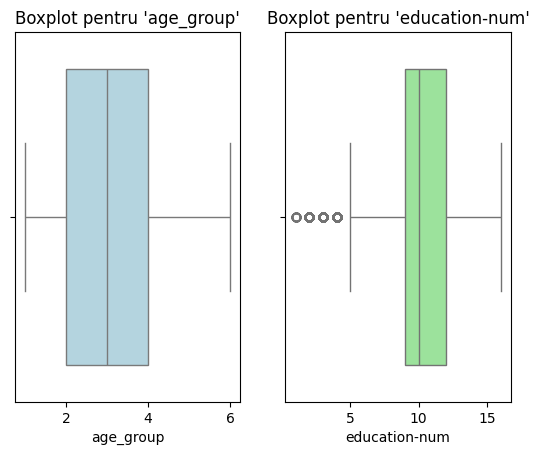

In [63]:
# Creating boxplots to observe the distributions of numerical variables
# Boxplot for 'age_group'
plt.subplot(1, 2, 1)
sns.boxplot(x=X_train['age_group'], color='lightblue')
plt.title("Boxplot pentru 'age_group'")

# Boxplot for 'education-num'
plt.subplot(1, 2, 2)
sns.boxplot(x=X_train['education-num'], color='lightgreen')
plt.title("Boxplot pentru 'education-num'")

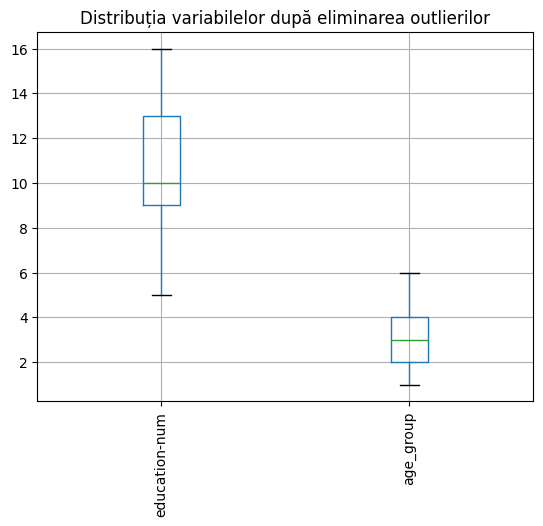

In [64]:
# Boxplot of variables after removing outliers from the training set
X_train_numeric_no_outliers.boxplot(rot=90)
plt.title("Distribuția variabilelor după eliminarea outlierilor")
plt.show()

In [65]:
# Scaling the numeric features
# Create a StandardScaler object
scaler = StandardScaler()

# Apply fit_transform on the training numeric data
X_train_scaled = scaler.fit_transform(X_train_numeric)

# Apply transform on the testing numeric data
X_test_scaled = scaler.transform(X_test_numeric)

In [66]:
# Display the first rows for verification
# Afișează primele 5 rânduri din X_train_scaled
print("Primele 5 rânduri din X_train_scaled:")
print(X_train_scaled[:5])

Primele 5 rânduri din X_train_scaled:
[[-0.42169353  0.07785464]
 [-0.42169353  0.80943535]
 [-0.03236778 -0.65372606]
 [-0.42169353  0.80943535]
 [-0.42169353 -0.65372606]]


In [67]:
# Display the first rows for verification
# Afișează primele 5 rânduri din X_train_scaled
print("Primele 5 rânduri din X_train_scaled:")
print(X_test_scaled[:5])

Primele 5 rânduri din X_train_scaled:
[[ 0.35695797 -0.65372606]
 [ 1.13560948 -1.38530676]
 [-0.03236778  1.54101605]
 [-0.03236778 -0.65372606]
 [ 1.13560948  0.07785464]]


In [68]:
# Check the unique values in the 'sex' column
print("Valori unice în coloana 'sex' (X_train):")
print(X_train['sex'].unique()) 

print("Valori unice în coloana 'sex' (X_test):")
print(X_test['sex'].unique())

Valori unice în coloana 'sex' (X_train):
['Female' 'Male']
Valori unice în coloana 'sex' (X_test):
['Male' 'Female']


In [69]:
# Applying manual encodinf for 'sex' and 'income' variables
def manual_encoding(X_train, X_test):
    """
    Manually encodes 'sex' (0 = male, 1 = female) and 'income' (0 = <=50k, 1 = >50k) in features.
    
    Parameters:
    - X_train: Training feature DataFrame
    - X_test: Testing feature DataFrame

    Returns:
    - Encoded X_train, X_test with integers instead of strings
    """
    X_train['sex'] = X_train['sex'].map({'Male': 0, 'Female': 1}).astype(int)
    X_test['sex'] = X_test['sex'].map({'Male': 0, 'Female': 1}).astype(int)

    X_train['income'] = X_train['income'].map({'<=50K': 0, '>50K': 1}).astype(int)
    X_test['income'] = X_test['income'].map({'<=50K': 0, '>50K': 1}).astype(int)

    return X_train, X_test
X_train, X_test = manual_encoding(X_train, X_test)

print("📌 Encoded 'sex' and 'income' columns (Check for integers):")
print(X_train[['sex', 'income']].dtypes)  
print(X_train[['sex', 'income']].head())

📌 Encoded 'sex' and 'income' columns (Check for integers):
sex       int64
income    int64
dtype: object
       sex  income
32239    1       0
30377    0       0
5457     0       1
19700    0       0
23197    0       0


In [70]:
X_train.head(15)

,workclass,education-num,marital-status,race,sex,income,age_group
32239,Private,9,Separated,White,1,0,3
30377,Private,9,Divorced,White,0,0,4
5457,Private,10,Married-civ-spouse,White,0,1,2
19700,Private,9,Divorced,Black,0,0,4
23197,Private,9,Married-civ-spouse,White,0,0,2
7424,Private,5,Married-civ-spouse,White,0,0,2
13028,Private,9,Divorced,White,0,0,5
9742,Private,9,Married-civ-spouse,White,0,0,5
12109,Private,13,Married-civ-spouse,White,0,1,4
327,Private,10,Married-civ-spouse,White,1,1,3


In [71]:
X_test.head(15)

,workclass,education-num,marital-status,race,sex,income,age_group
3643,State-gov,11,Married-civ-spouse,White,0,0,2
16042,Federal-gov,13,Never-married,White,0,0,1
9404,Local-gov,10,Married-civ-spouse,Asian-Pac-Islander,0,0,5
17910,Private,10,Never-married,White,0,0,2
5200,Federal-gov,13,Never-married,White,0,1,3
28785,Private,9,Divorced,Amer-Indian-Eskimo,1,0,4
4638,State-gov,6,Divorced,Black,1,0,6
1487,Private,9,Never-married,White,1,0,2
20382,Private,9,Married-civ-spouse,White,1,1,5
9814,Private,14,Married-civ-spouse,White,0,1,4


In [72]:
# Using One-Hot-Encoder
# Initialize OneHotEncoder with sparse_output=False
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Apply one-hot encoding to categorical columns (excluding already encoded ones like 'sex' and 'income')
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Fit and transform on training data
encoder.fit(X_train[categorical_cols])  # Fit ONLY on X_train

X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Get feature names AFTER fitting
encoded_columns = encoder.get_feature_names_out(categorical_cols)

# Create DataFrames from the encoded data and convert values to integers (0 or 1)
X_train_encoded_df = pd.DataFrame(X_train_encoded, index=X_train.index, columns=encoded_columns)
X_test_encoded_df = pd.DataFrame(X_test_encoded, index=X_test.index, columns=encoded_columns)

# Convert the encoded DataFrames to integers (0 or 1)
X_train_encoded_df = X_train_encoded_df.astype(int)
X_test_encoded_df = X_test_encoded_df.astype(int)

# Concatenate encoded features with the original numerical features
X_train = pd.concat([X_train.drop(categorical_cols, axis=1), X_train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(categorical_cols, axis=1), X_test_encoded_df], axis=1)

In [73]:
X_train.head()

,education-num,sex,income,age_group,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,race_Asian-Pac-Islander,race_Black,race_Other,race_White
32239,9,1,0,3,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
30377,9,0,0,4,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5457,10,0,1,2,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
19700,9,0,0,4,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
23197,9,0,0,2,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [74]:
X_test.head()

,education-num,sex,income,age_group,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,race_Asian-Pac-Islander,race_Black,race_Other,race_White
3643,11,0,0,2,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
16042,13,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
9404,10,0,0,5,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
17910,10,0,0,2,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
5200,13,0,1,3,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [75]:
# Save X_train and X_test to CSV files
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)

# Save y_train and y_test to CSV files (if you have the target variables separately)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)